# Hierarchical Multifidelity Triangular Maps Tutorial

This notebook is a compact, end-to-end introduction to the hierarchical multifidelity `HierarchicalTriangularMap` API. We learn transports for a high-, middle-, and low-fidelity banana hierarchy, compare `changing_reference` and `fixed_reference`, and use both fits for pushforwards, inverse sampling, conditional sampling, and density evaluation.


## Paper notation used in this notebook

This notebook implements Section 4.1. Fidelity is indexed by
$\ell=0,\ldots,M$, with $\ell=0$ high fidelity and
$\ell=1,\ldots,M$ lower fidelity. The list `X_ell[ell]` represents the
paper's dataset $\mathcal X_\ell=\{x_\ell^{(j)}\}_{j=1}^{N_\ell}$; its rows
are the individual samples. The changing-reference stages are $A_\ell$ with
map-induced references $q_\ell$ (equations (4.3)--(4.8)), while the
fixed-reference stages are $B_\ell$ with transformed data $y_\ell$
(equations (4.9)--(4.15)). The final estimates are `S_hat_H_CR` =
$\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}$ and `S_hat_H_FR` =
$\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}FR}}$.

## 1. The analytic tri-fidelity banana example

For fidelity $\ell$, let $Z\sim\eta=\mathcal N(0,I)$ and define $X_1^{(\ell)}=s_\ell Z_1$ and $X_2^{(\ell)}=Z_2+b_\ell(Z_1^2-1)$. The exact transport to the reference is $\boldsymbol{S}_\ell(x)=[x_1/s_\ell,\ x_2-b_\ell((x_1/s_\ell)^2-1)]^T$.

Training data are ordered high-to-low, while HMF trains stages low-to-high. Changing-reference stages use map-induced references; fixed-reference stages use Gaussian references after lower-stage transformations.


In [4]:
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from mftt import MapParams, OptimizationParams

SEED = 101
rng = np.random.default_rng(SEED)
INPUT_DIM = 2

TARGET_COLOR = "#E76F51"
REFERENCE_COLOR = "#457B9D"
LEARNED_COLOR = "#2A9D8F"
ALTERNATE_COLOR = "#8E5EA2"
MIDDLE_FIDELITY_COLOR = "#43AA8B"
LOW_FIDELITY_COLOR = "#6A77E9"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "font.size": 10,
})

from mftt import HierarchicalMapParams, HierarchicalTriangularMap


## 2. Sampling and density helpers

The helpers below use the same names and batch conventions as the single-fidelity tutorial.


In [5]:
def banana_sample(n_samples, rng, scale_x=1.0, bend=0.5):
    """Draw samples from an analytic banana target."""
    z = rng.standard_normal((n_samples, 2))
    return S_ell_inverse(z, scale_x=scale_x, bend=bend)


def S_ell(x, scale_x=1.0, bend=0.5):
    """Map banana samples to the standard-Gaussian reference."""
    x = np.asarray(x, dtype=float)
    z = x.copy()
    z[:, 0] = x[:, 0] / scale_x
    z[:, 1] = x[:, 1] - bend * (z[:, 0] ** 2 - 1.0)
    return z


def S_ell_inverse(z, scale_x=1.0, bend=0.5):
    """Map standard-Gaussian samples to the banana target."""
    z = np.asarray(z, dtype=float)
    x = z.copy()
    x[:, 0] = scale_x * z[:, 0]
    x[:, 1] = z[:, 1] + bend * (z[:, 0] ** 2 - 1.0)
    return x


def standard_normal_logpdf(z):
    z = np.asarray(z, dtype=float)
    return -0.5 * np.sum(z * z, axis=1) - np.log(2.0 * np.pi)


def banana_logpdf(x, scale_x=1.0, bend=0.5):
    return standard_normal_logpdf(S_ell(x, scale_x=scale_x, bend=bend)) - np.log(scale_x)


def normal_pdf_1d(values, mean=0.0, std=1.0):
    values = np.asarray(values, dtype=float)
    scaled = (values - mean) / std
    return np.exp(-0.5 * scaled * scaled) / (np.sqrt(2.0 * np.pi) * std)


def make_grid(x_limits, y_limits, n=220):
    x1 = np.linspace(*x_limits, n)
    x2 = np.linspace(*y_limits, n)
    xx, yy = np.meshgrid(x1, x2)
    return xx, yy, np.column_stack((xx.ravel(), yy.ravel()))


def style_joint_axis(ax, x_label=r"$x_1$", y_label=r"$x_2$", limits=(-4.0, 4.0, -4.5, 4.5)):
    ax.set(xlabel=x_label, ylabel=y_label, xlim=limits[:2], ylim=limits[2:])
    ax.set_aspect("equal", adjustable="box")


## 3. Target and reference at a glance

The three target panels show the fidelity hierarchy; the fourth panel shows the common Gaussian reference.


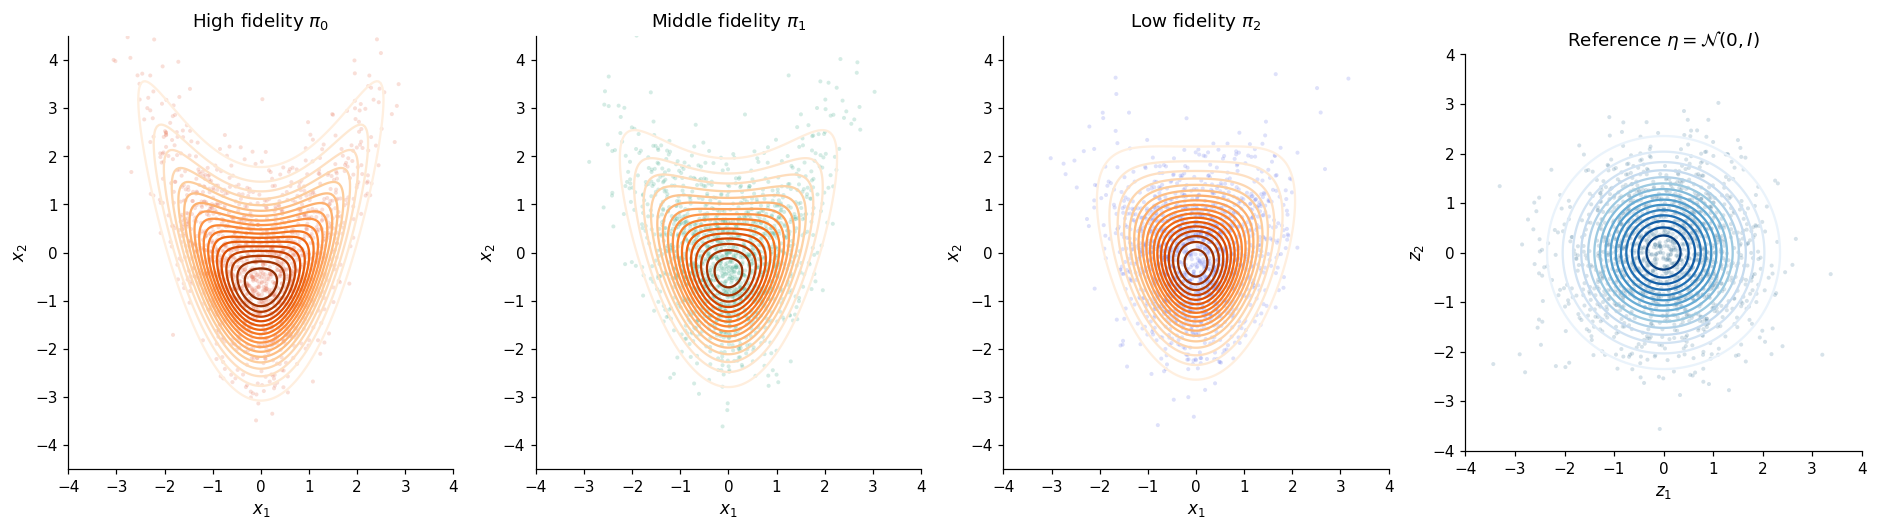

In [10]:
FIDELITY_PARAMS = [
    {"scale_x": 1.05, "bend": 0.65},
    {"scale_x": 0.95, "bend": 0.42},
    {"scale_x": 0.85, "bend": 0.22},
]
FIDELITY_NAMES = ["High fidelity $\pi_0$", "Middle fidelity $\pi_1$", "Low fidelity $\pi_2$"]
FIDELITY_COLORS = [TARGET_COLOR, MIDDLE_FIDELITY_COLOR, LOW_FIDELITY_COLOR]

N_ell = [4000, 5000, 6000]
N_test = 6000
N_display = 1500
X_ell = [banana_sample(n, rng, **params) for n, params in zip(N_ell, FIDELITY_PARAMS)]
x_0_test = banana_sample(N_test, rng, **FIDELITY_PARAMS[0])
z_reference_display = rng.standard_normal((N_display, INPUT_DIM))

x_xx, x_yy, x_grid = make_grid((-4.5, 4.5), (-4.5, 4.5))
z_xx, z_yy, z_grid = make_grid((-4.0, 4.0), (-4.0, 4.0))
true_target_densities = [
    np.exp(banana_logpdf(x_grid, **params)).reshape(x_xx.shape)
    for params in FIDELITY_PARAMS
]
reference_density = np.exp(standard_normal_logpdf(z_grid)).reshape(z_xx.shape)

assert np.allclose(
    S_ell_inverse(S_ell(x_0_test[:128], **FIDELITY_PARAMS[0]), **FIDELITY_PARAMS[0]),
    x_0_test[:128],
)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), constrained_layout=True)
for axis, density, samples, title, color in zip(
    axes[:3], true_target_densities, X_ell, FIDELITY_NAMES, FIDELITY_COLORS
):
    axis.contour(x_xx, x_yy, density, levels=18, cmap="Oranges")
    axis.scatter(samples[:N_display, 0], samples[:N_display, 1], s=7, alpha=0.22, color=color, edgecolors="none")
    axis.set_title(title)
    style_joint_axis(axis)
axes[3].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[3].scatter(z_reference_display[:, 0], z_reference_display[:, 1], s=7, alpha=0.22, color=REFERENCE_COLOR, edgecolors="none")
axes[3].set_title(r"Reference $\eta=\mathcal{N}(0,I)$")
style_joint_axis(axes[3], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 4. Construct two hierarchical maps

Both models use the same per-fidelity total-order parameterization. The training method is selected explicitly at training time.


In [13]:
optimization = OptimizationParams(
    optimizer="BFGS", reg_cst=1e-10, gtol=1e-8, maxiter=120
)
hierarchical_params = HierarchicalMapParams(
    fidelity_map_params=[
        MapParams(total_order=2, optimization=optimization)
        for _ in FIDELITY_PARAMS
    ]
)
S_hat_H_CR = HierarchicalTriangularMap(
    [data.copy() for data in X_ell], hierarchical_params
)
S_hat_H_FR = HierarchicalTriangularMap(
    [data.copy() for data in X_ell], hierarchical_params
)
print(S_hat_H_CR)
print(S_hat_H_FR)

#Notice below that method=untrained ----> Training with either fixed or changing reference will update this field


HierarchicalTriangularMap(family=hierarchical_multifidelity, input_dim=2, num_fidelities=3, method=untrained, samples=[4000, 5000, 6000])
HierarchicalTriangularMap(family=hierarchical_multifidelity, input_dim=2, num_fidelities=3, method=untrained, samples=[4000, 5000, 6000])


## 5. Training the maps

We retain both method-specific fits for all downstream diagnostics.


In [14]:
start = time.perf_counter()
S_hat_H_CR.train(method="changing_reference", verbose=True)
changing_reference_seconds = time.perf_counter() - start

start = time.perf_counter()
S_hat_H_FR.train(method="fixed_reference", verbose=True)
fixed_reference_seconds = time.perf_counter() - start

print(f"Changing-reference training time: {changing_reference_seconds:.2f} s")
print(f"Fixed-reference training time: {fixed_reference_seconds:.2f} s")
print("Changing-reference evaluation order:", S_hat_H_CR.evaluation_order)
print("Fixed-reference evaluation order:", S_hat_H_FR.evaluation_order)


Completed stage 1/3 for method 'changing_reference' (fidelity index 2).
Completed stage 2/3 for method 'changing_reference' (fidelity index 1).
Completed stage 3/3 for method 'changing_reference' (fidelity index 0).
Completed stage 1/3 for method 'fixed_reference' (fidelity index 2).
Completed stage 2/3 for method 'fixed_reference' (fidelity index 1).
Completed stage 3/3 for method 'fixed_reference' (fidelity index 0).
Changing-reference training time: 9.86 s
Fixed-reference training time: 1.03 s
Changing-reference evaluation order: [0, 1, 2]
Fixed-reference evaluation order: [2, 1, 0]


## 6. Compare the learned pushforwards

`partial_evaluations(x)` exposes the HF-standardized state and every stage state, so the composition remains visible alongside the final pushforward comparison.


### Changing-reference HMF $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}$

coefficients: 27; training: 9.86 s
RMSE against exact HF transport: 0.0680
max round-trip error: 2.01e-08


### Fixed-reference HMF $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}FR}}$

coefficients: 27; training: 1.03 s
RMSE against exact HF transport: 0.0676
max round-trip error: 1.56e-08


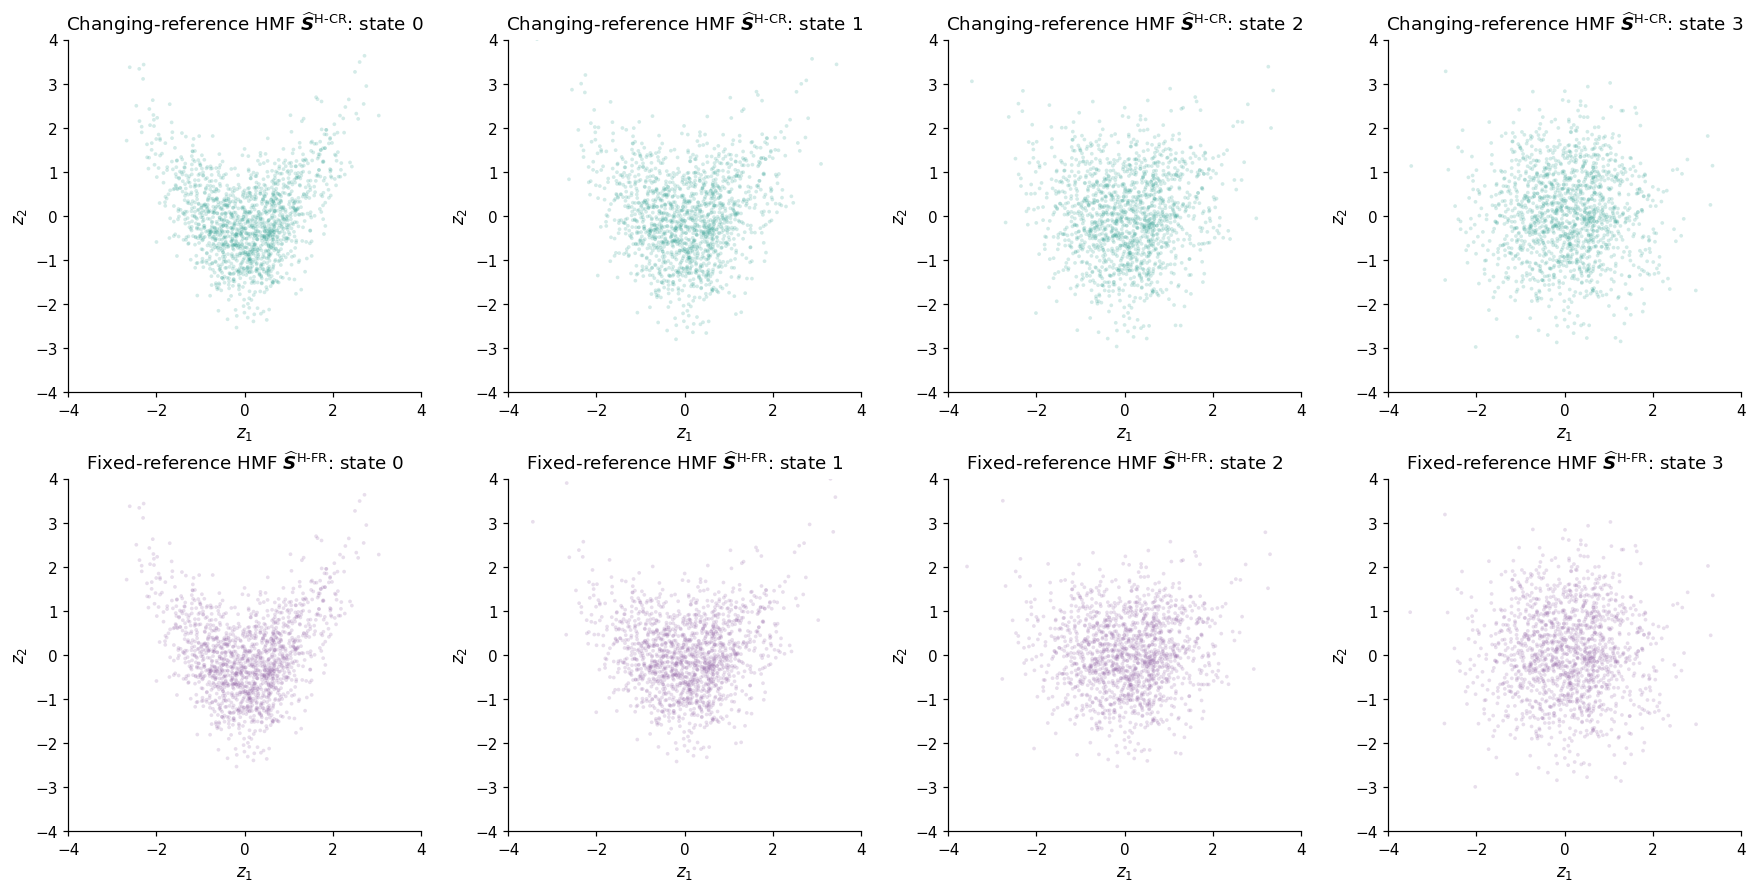

In [16]:
def map_summary(name, model, elapsed_seconds):
    z_hat = model.evaluate(x_0_test)
    exact_z = S_ell(x_0_test, **FIDELITY_PARAMS[0])
    recovered = model.inverse(z_hat[:512])
    round_trip_error = np.max(np.abs(recovered - x_0_test[:512]))
    assert round_trip_error < 1e-6
    return {
        "name": name,
        "coefficients": model.coefficients.flatten().size,
        "seconds": elapsed_seconds,
        "S_rmse": float(np.sqrt(np.mean((z_hat - exact_z) ** 2))),
        "round_trip_error": float(round_trip_error),
        "z_hat": z_hat,
        "states": model.partial_evaluations(x_0_test[:N_display]),
    }

summaries = [
    map_summary(r"Changing-reference HMF $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}$", S_hat_H_CR, changing_reference_seconds),
    map_summary(r"Fixed-reference HMF $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}FR}}$", S_hat_H_FR, fixed_reference_seconds),
]
for result in summaries:
    display(Markdown(f"### {result['name']}"))
    print(f"coefficients: {result['coefficients']}; training: {result['seconds']:.2f} s")
    print(f"RMSE against exact HF transport: {result['S_rmse']:.4f}")
    print(f"max round-trip error: {result['round_trip_error']:.2e}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for row, result, color in zip(range(2), summaries, [LEARNED_COLOR, ALTERNATE_COLOR]):
    for stage_index, state in enumerate(result["states"]):
        axes[row, stage_index].scatter(state[:, 0], state[:, 1], s=6, alpha=0.2, color=color, edgecolors="none")
        axes[row, stage_index].set_title(f"{result['name']}: state {stage_index}")
        style_joint_axis(axes[row, stage_index], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 7. Unconditional target sampling via inverse maps

Draw $z\sim\eta$ and apply each learned inverse.


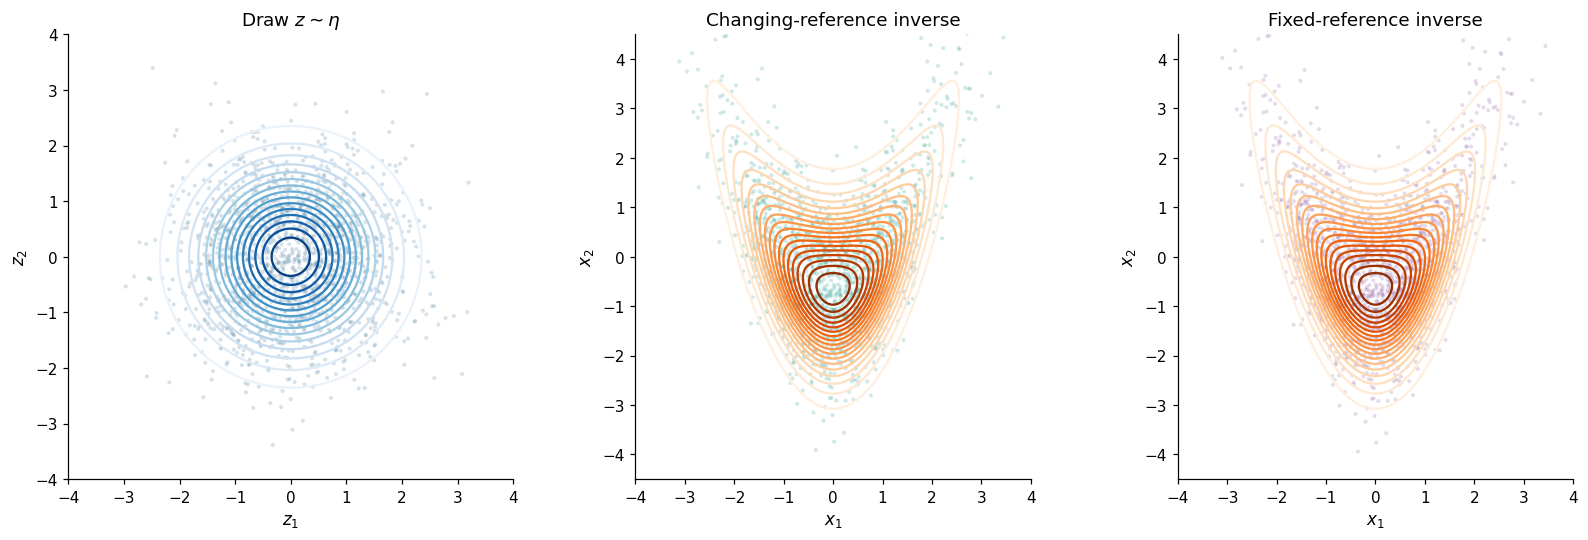

In [18]:
N_generate = 5000
sampling_seed = 404
sampling_rng = np.random.default_rng(sampling_seed)
z_draws = sampling_rng.standard_normal((N_generate, INPUT_DIM))
x_draws_changing = S_hat_H_CR.inverse(z_draws)
x_draws_fixed = S_hat_H_FR.inverse(z_draws)
assert np.allclose(x_draws_changing, S_hat_H_CR.sample(N_generate, random_state=sampling_seed))
assert np.allclose(x_draws_fixed, S_hat_H_FR.sample(N_generate, random_state=sampling_seed))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
axes[0].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[0].scatter(z_draws[:N_display, 0], z_draws[:N_display, 1], s=7, alpha=0.22, color=REFERENCE_COLOR, edgecolors="none")
axes[0].set_title(r"Draw $z\sim\eta$")
style_joint_axis(axes[0], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
for axis, samples, title, color in zip(
    axes[1:], [x_draws_changing, x_draws_fixed],
    ["Changing-reference inverse", "Fixed-reference inverse"],
    [LEARNED_COLOR, ALTERNATE_COLOR],
):
    axis.contour(x_xx, x_yy, true_target_densities[0], levels=18, cmap="Oranges")
    axis.scatter(samples[:N_display, 0], samples[:N_display, 1], s=7, alpha=0.22, color=color, edgecolors="none")
    axis.set_title(title)
    style_joint_axis(axis)
plt.show()


## 8. Conditional sampling and conditional density

We condition on $X_1=1.0$ and compare both learned conditionals with the analytic HF conditional.


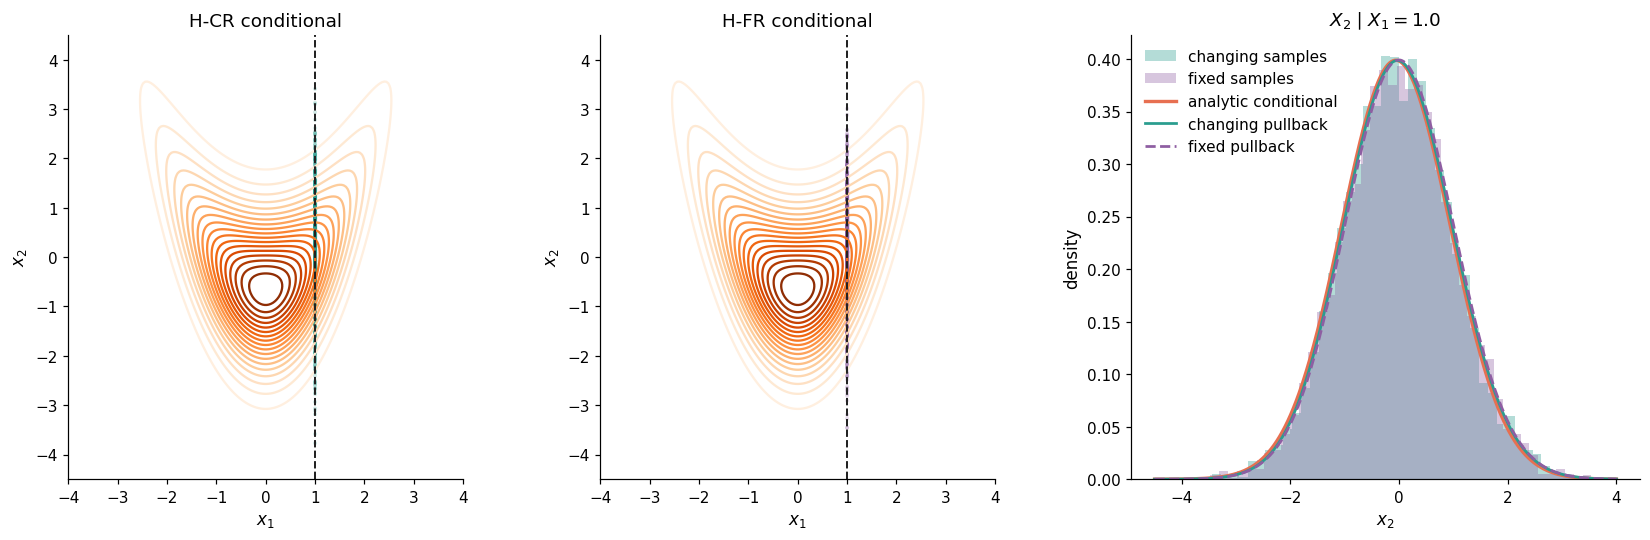

In [19]:
conditioned_x1 = 1.0
N_conditional = 5000
conditional_samples_changing = S_hat_H_CR.conditional_sample(N_conditional, fixed_indices=[0], fixed_values=np.array([conditioned_x1]), random_state=808)
conditional_samples_fixed = S_hat_H_FR.conditional_sample(N_conditional, fixed_indices=[0], fixed_values=np.array([conditioned_x1]), random_state=809)
assert np.allclose(conditional_samples_changing[:, 0], conditioned_x1)
assert np.allclose(conditional_samples_fixed[:, 0], conditioned_x1)
x2_conditional_grid = np.linspace(-4.5, 4.0, 500)
conditional_grid = np.column_stack((np.full_like(x2_conditional_grid, conditioned_x1), x2_conditional_grid))
true_conditional_mean = FIDELITY_PARAMS[0]["bend"] * ((conditioned_x1 / FIDELITY_PARAMS[0]["scale_x"]) ** 2 - 1.0)
true_pi_0_conditional_density = normal_pdf_1d(x2_conditional_grid, mean=true_conditional_mean)
learned_pi_0_conditional_H_CR = S_hat_H_CR.conditional_pullback_pdf(conditional_grid, fixed_indices=[0])
learned_pi_0_conditional_H_FR = S_hat_H_FR.conditional_pullback_pdf(conditional_grid, fixed_indices=[0])
assert np.all(np.isfinite(learned_pi_0_conditional_H_CR)) and np.all(learned_pi_0_conditional_H_CR >= 0.0)
assert np.all(np.isfinite(learned_pi_0_conditional_H_FR)) and np.all(learned_pi_0_conditional_H_FR >= 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for axis, samples, title, color in zip(axes[:2], [conditional_samples_changing, conditional_samples_fixed], ["H-CR conditional", "H-FR conditional"], [LEARNED_COLOR, ALTERNATE_COLOR]):
    axis.contour(x_xx, x_yy, true_target_densities[0], levels=18, cmap="Oranges")
    axis.scatter(samples[:N_display, 0], samples[:N_display, 1], s=7, alpha=0.2, color=color, edgecolors="none")
    axis.axvline(conditioned_x1, color="#222222", linestyle="--", linewidth=1.3)
    axis.set_title(title)
    style_joint_axis(axis)
axes[2].hist(conditional_samples_changing[:, 1], bins=45, density=True, alpha=0.35, color=LEARNED_COLOR, label="changing samples")
axes[2].hist(conditional_samples_fixed[:, 1], bins=45, density=True, alpha=0.35, color=ALTERNATE_COLOR, label="fixed samples")
axes[2].plot(x2_conditional_grid, true_pi_0_conditional_density, color=TARGET_COLOR, linewidth=2.2, label="analytic conditional")
axes[2].plot(x2_conditional_grid, learned_pi_0_conditional_H_CR, color=LEARNED_COLOR, linewidth=1.8, label="changing pullback")
axes[2].plot(x2_conditional_grid, learned_pi_0_conditional_H_FR, color=ALTERNATE_COLOR, linestyle="--", linewidth=1.8, label="fixed pullback")
axes[2].set(title=rf"$X_2\mid X_1={conditioned_x1}$", xlabel=r"$x_2$", ylabel="density")
axes[2].legend(frameon=False)
plt.show()


## 9. The map-induced joint target density

For either learned composition, `pullback_pdf(x)` applies the change-of-variables formula.
The H-CR density is $\widehat\pi_0(x)=\eta(\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}(x))|\det\nabla\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}(x)|$; H-FR is analogous.


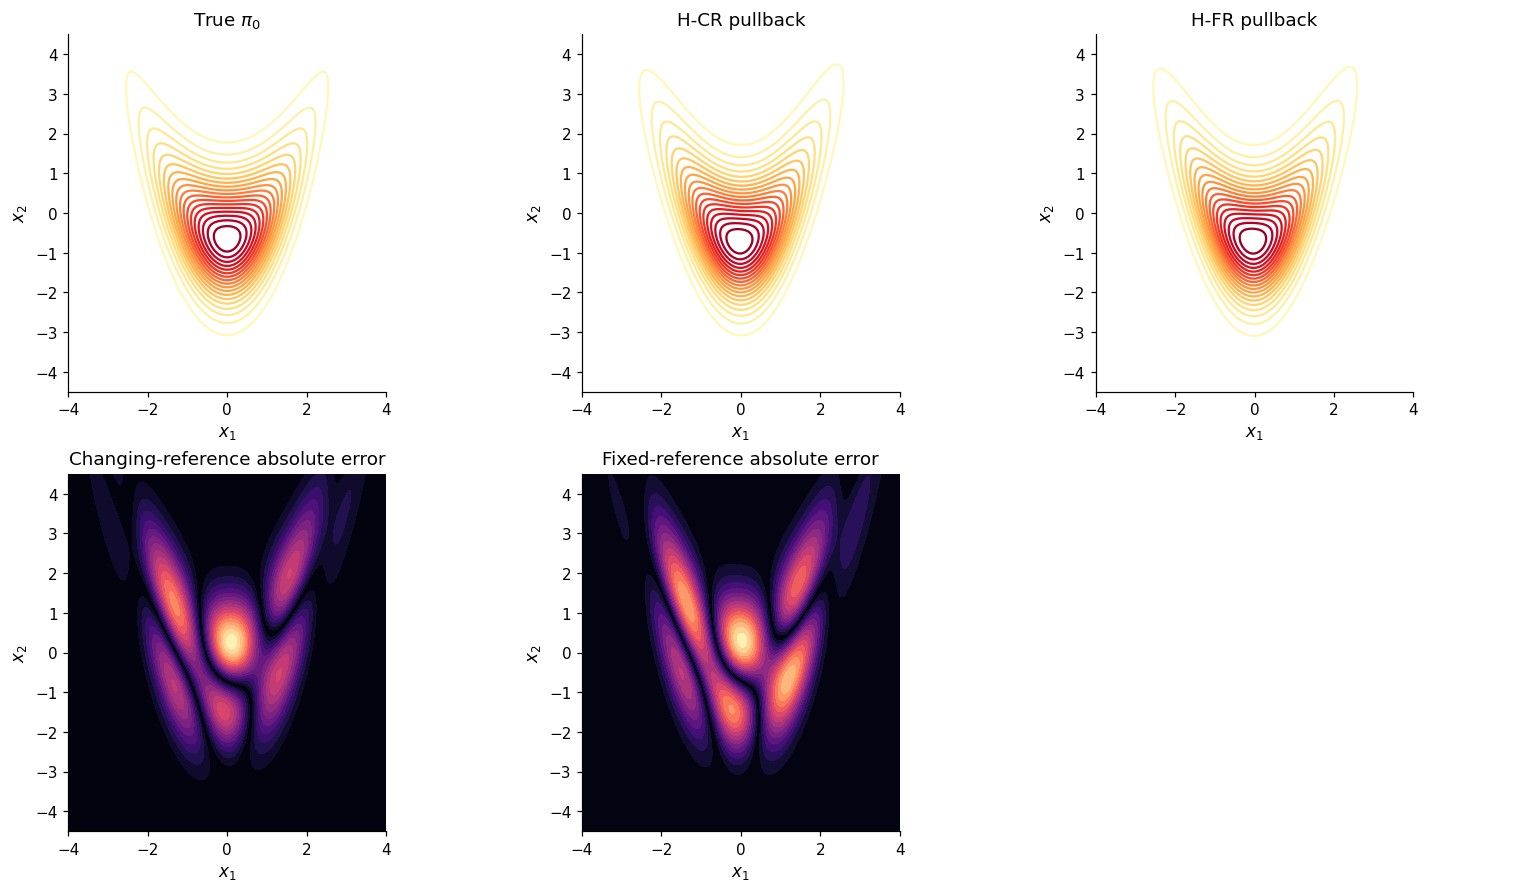

In [20]:
learned_pi_0_density_H_CR = S_hat_H_CR.pullback_pdf(x_grid).reshape(x_xx.shape)
learned_pi_0_density_H_FR = S_hat_H_FR.pullback_pdf(x_grid).reshape(x_xx.shape)
assert np.all(np.isfinite(learned_pi_0_density_H_CR)) and np.all(learned_pi_0_density_H_CR >= 0.0)
assert np.all(np.isfinite(learned_pi_0_density_H_FR)) and np.all(learned_pi_0_density_H_FR >= 0.0)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for axis, density, title in zip(axes[0], [true_target_densities[0], learned_pi_0_density_H_CR, learned_pi_0_density_H_FR], [r"True $\pi_0$", "H-CR pullback", "H-FR pullback"]):
    axis.contour(x_xx, x_yy, density, levels=18, cmap="YlOrRd")
    axis.set_title(title)
    style_joint_axis(axis)
for axis, error, title in zip(axes[1, :2], [abs(learned_pi_0_density_H_CR-true_target_densities[0]), abs(learned_pi_0_density_H_FR-true_target_densities[0])], ["Changing-reference absolute error", "Fixed-reference absolute error"]):
    axis.contourf(x_xx, x_yy, error, levels=18, cmap="magma")
    axis.set_title(title)
    style_joint_axis(axis)
axes[1, 2].axis("off")
plt.show()


## 10. Math-to-API summary

| Task | Mathematical operation | API call |
| --- | --- | --- |
| Train changing-reference HMF | map-induced stage references | `train(method="changing_reference")` |
| Train fixed-reference HMF | transformed stage data and Gaussian references | `train(method="fixed_reference")` |
| Inspect stage composition | HF chart plus stage states | `partial_evaluations(x)` |
| Push samples to reference | $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}}(x)$ or $\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}FR}}(x)$ | `evaluate(x)` |
| Pull samples to target | $(\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}CR}})^{-1}(z)$ or $(\widehat{\boldsymbol{S}}^{\mathrm{H\text{-}FR}})^{-1}(z)$ | `inverse(z)` / `sample(...)` |
| Evaluate learned densities | change of variables | `pullback_pdf(...)` / `conditional_pullback_pdf(...)` |
